In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Organization_ECommerce_Data_Analytics_Assignment.csv")
print(df)

    Transaction_ID        Date Customer_ID Customer_Segment Region  \
0           T00001  2026-08-03       C0075          Regular  South   
1           T00002  2026-06-19       C0015          Regular  North   
2           T00003  2026-08-30       C0009          Premium   West   
3           T00004  2026-02-23       C0106          Regular  South   
4           T00005  2026-02-22       C0024          Regular   West   
..             ...         ...         ...              ...    ...   
603         T00455  2026-09-13       C0056          Premium   East   
604         T00338  2026-02-02       C0012           Budget  North   
605         T00581  2026-05-09       C0035          Premium  South   
606         T00317  2026-09-02       C0107          Regular   East   
607         T00440  2026-04-04       C0138          Regular   East   

            City Product_ID       Product         Category  Quantity  ...  \
0      Bengaluru       P002    Smartphone      Electronics         4  ...   
1    

In [3]:
#Dataset dimensions
print("Number of rows:",
      df.shape[0])
print("Number of columns:",
      df.shape[1])

Number of rows: 608
Number of columns: 21


In [4]:
#First look
df.head()

,Transaction_ID,Date,Customer_ID,Customer_Segment,Region,City,Product_ID,Product,Category,Quantity,...,Discount_Percent,Payment_Method,Sales_Channel,Customer_Rating,Delivery_Days,Gross_Sales,Discount_Amount,Net_Sales,Cost,Profit
0,T00001,2026-08-03,C0075,Regular,South,Bengaluru,P002,Smartphone,Electronics,4,...,10.0,Cash,Mobile App,3.6,3,139008.76,13900.88,125107.88,112000,13107.88
1,T00002,2026-06-19,C0015,Regular,North,Jaipur,P006,Study Table,Furniture,2,...,10.0,Debit Card,Website,4.0,5,14367.04,1436.70,12930.34,12400,530.34
2,T00003,2026-08-30,C0009,Premium,West,Ahmedabad,P002,Smartphone,Electronics,1,...,25.0,Credit Card,Mobile App,3.3,4,37413.57,9353.39,28060.18,28000,60.18
3,T00004,2026-02-23,C0106,Regular,South,Hyderabad,P002,Smartphone,Electronics,2,...,15.0,Cash,Marketplace,4.1,6,63235.40,9485.31,53750.09,56000,-2249.91
4,T00005,2026-02-22,C0024,Regular,West,Pune,P002,Smartphone,Electronics,1,...,10.0,debit card,Mobile App,3.4,2,32699.50,3269.95,29429.55,28000,1429.55


In [5]:
df.tail()

,Transaction_ID,Date,Customer_ID,Customer_Segment,Region,City,Product_ID,Product,Category,Quantity,...,Discount_Percent,Payment_Method,Sales_Channel,Customer_Rating,Delivery_Days,Gross_Sales,Discount_Amount,Net_Sales,Cost,Profit
603,T00455,2026-09-13,C0056,Premium,East,Patna,P010,Air Fryer,Home Appliances,2,...,10.0,UPI,Mobile App,3.3,4,18829.38,1882.94,16946.44,14400,2546.44
604,T00338,2026-02-02,C0012,Budget,North,Jaipur,P005,Office Chair,Furniture,2,...,0.0,Debit Card,Website,4.2,1,21041.62,0.00,21041.62,15600,5441.62
605,T00581,2026-05-09,C0035,Premium,South,Hyderabad,P002,Smartphone,Electronics,2,...,15.0,Credit Card,Website,3.6,3,70515.66,10577.35,59938.31,56000,3938.31
606,T00317,2026-09-02,C0107,Regular,East,Bhubaneswar,P004,Keyboard,Electronics,2,...,20.0,Debit Card,Mobile App,3.4,3,5422.30,1084.46,4337.84,4400,-62.16
607,T00440,2026-04-04,C0138,Regular,East,Bhubaneswar,P007,Backpack,Fashion,3,...,10.0,Net Banking,Website,4.7,5,6600.45,660.04,5940.41,5400,540.41


In [6]:
#Column names
df.columns

Index(['Transaction_ID', 'Date', 'Customer_ID', 'Customer_Segment', 'Region',
       'City', 'Product_ID', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Discount_Percent', 'Payment_Method', 'Sales_Channel',
       'Customer_Rating', 'Delivery_Days', 'Gross_Sales', 'Discount_Amount',
       'Net_Sales', 'Cost', 'Profit'],
      dtype='object')

In [7]:
#Data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608 entries, 0 to 607
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    608 non-null    object 
 1   Date              608 non-null    object 
 2   Customer_ID       608 non-null    object 
 3   Customer_Segment  608 non-null    object 
 4   Region            597 non-null    object 
 5   City              608 non-null    object 
 6   Product_ID        608 non-null    object 
 7   Product           608 non-null    object 
 8   Category          608 non-null    object 
 9   Quantity          608 non-null    int64  
 10  Unit_Price        601 non-null    float64
 11  Discount_Percent  593 non-null    float64
 12  Payment_Method    597 non-null    object 
 13  Sales_Channel     608 non-null    object 
 14  Customer_Rating   599 non-null    float64
 15  Delivery_Days     608 non-null    int64  
 16  Gross_Sales       608 non-null    float64
 1

In [8]:
#Statistical summary
df.describe()

,Quantity,Unit_Price,Discount_Percent,Customer_Rating,Delivery_Days,Gross_Sales,Discount_Amount,Net_Sales,Cost,Profit
count,608.000000,601.000000,593.000000,599.000000,608.000000,608.000000,608.000000,608.000000,608.000000,608.000000
mean,2.519737,13731.088586,10.244519,3.945075,4.141447,35183.267780,3724.522928,31458.744852,29026.480263,2432.264589
std,1.794079,17526.008517,6.529500,0.633252,2.568930,56053.276051,7182.456477,50509.680187,46237.674499,6923.488643
min,1.000000,1948.850000,0.000000,1.000000,1.000000,1948.850000,0.000000,1656.520000,1800.000000,-17649.170000
25%,1.000000,3798.290000,5.000000,3.500000,3.000000,7005.842500,426.360000,6345.202500,6200.000000,59.937500
50%,2.000000,6397.910000,10.000000,4.000000,4.000000,12529.985000,1170.680000,11623.390000,10050.000000,673.385000
75%,3.000000,9717.020000,15.000000,4.400000,5.000000,30686.115000,3306.555000,27778.290000,25600.000000,2135.977500
max,25.000000,69686.060000,25.000000,5.000000,30.000000,356565.060000,63986.310000,356565.060000,312000.000000,62312.390000


In [9]:
#Number of unique values
df.nunique()

,0
Transaction_ID,600
Date,239
Customer_ID,148
Customer_Segment,3
Region,4
City,12
Product_ID,10
Product,10
Category,4
Quantity,8


In [10]:
print("Number of customers:", df['Customer_ID'].nunique())
print("Number of products:", df['Product'].nunique())
print("Number of categories:", df['Category'].nunique())
print("Number of regions:", df['Region'].nunique())
print("Number of cities:", df['City'].nunique())
print("Number of customer segments:", df['Customer_Segment'].nunique())


Number of customers: 148
Number of products: 10
Number of categories: 4
Number of regions: 4
Number of cities: 12
Number of customer segments: 3


In [11]:
#Date
df["Date"] = pd.to_datetime(df["Date"])
print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())

Earliest date: 2026-01-01 00:00:00
Latest date: 2026-09-30 00:00:00


In [12]:
#Categorical Data Exploration
print("Customer Segments:")
print(df["Customer_Segment"].value_counts())

Customer Segments:
Customer_Segment
Regular    320
Budget     161
Premium    127
Name: count, dtype: int64


In [13]:
print("Regions:")
print(df['Region'].value_counts(dropna = False))

Regions:
Region
South    193
West     175
North    129
East     100
NaN       11
Name: count, dtype: int64


In [14]:
print("Cities:")
print(df['Product'].value_counts())

Cities:
Product
Smartphone       80
Backpack         68
Coffee Maker     64
Office Chair     63
Running Shoes    63
Headphones       63
Keyboard         54
Air Fryer        53
Study Table      51
Laptop           49
Name: count, dtype: int64


In [15]:
print("Categories:")
print(df['Category'].value_counts())

Categories:
Category
Electronics        246
Fashion            131
Home Appliances    117
Furniture          114
Name: count, dtype: int64


In [16]:
print("Payment Methods")
print(df['Payment_Method'].value_counts())

Payment Methods
Payment_Method
Debit Card     126
Credit Card    121
Cash           120
UPI            111
Net Banking    101
debit card       6
upi              6
Credit card      6
Name: count, dtype: int64


In [17]:
print("Sales Channels")
print(df['Sales_Channel'].value_counts())

Sales Channels
Sales_Channel
Website        261
Mobile App     222
Marketplace    125
Name: count, dtype: int64


In [18]:
#Data Quality Check
#Missing values
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100)
})

missing[missing['Missing_Count'] > 0].sort_values(
    'Missing_Count',
    ascending=False
)

,Missing_Count,Missing_Percentage
Discount_Percent,15,2.467105
Region,11,1.809211
Payment_Method,11,1.809211
Customer_Rating,9,1.480263
Unit_Price,7,1.151316


In [19]:
#Duplicates
print("Duplicate rows:",
      df.duplicated().sum())
print("Duplicate Transaction IDs:",
      df['Transaction_ID'].duplicated().sum())


Duplicate rows: 8
Duplicate Transaction IDs: 8


In [20]:
df[df["Transaction_ID"].duplicated(keep = False)].sort_values('Transaction_ID')

,Transaction_ID,Date,Customer_ID,Customer_Segment,Region,City,Product_ID,Product,Category,Quantity,...,Discount_Percent,Payment_Method,Sales_Channel,Customer_Rating,Delivery_Days,Gross_Sales,Discount_Amount,Net_Sales,Cost,Profit
132,T00133,2026-09-23,C0089,Premium,North,Jaipur,P007,Backpack,Fashion,2,...,10.0,Debit Card,Mobile App,3.0,6,4263.64,426.36,3837.28,3600,237.28
601,T00133,2026-09-23,C0089,Premium,North,Jaipur,P007,Backpack,Fashion,2,...,10.0,Debit Card,Mobile App,3.0,6,4263.64,426.36,3837.28,3600,237.28
261,T00262,2026-09-26,C0011,Regular,West,Pune,P006,Study Table,Furniture,3,...,10.0,Debit Card,Website,4.7,30,20873.82,2087.38,18786.44,18600,186.44
600,T00262,2026-09-26,C0011,Regular,West,Pune,P006,Study Table,Furniture,3,...,10.0,Debit Card,Website,4.7,30,20873.82,2087.38,18786.44,18600,186.44
316,T00317,2026-09-02,C0107,Regular,East,Bhubaneswar,P004,Keyboard,Electronics,2,...,20.0,Debit Card,Mobile App,3.4,3,5422.30,1084.46,4337.84,4400,-62.16
606,T00317,2026-09-02,C0107,Regular,East,Bhubaneswar,P004,Keyboard,Electronics,2,...,20.0,Debit Card,Mobile App,3.4,3,5422.30,1084.46,4337.84,4400,-62.16
337,T00338,2026-02-02,C0012,Budget,North,Jaipur,P005,Office Chair,Furniture,2,...,0.0,Debit Card,Website,4.2,1,21041.62,0.00,21041.62,15600,5441.62
604,T00338,2026-02-02,C0012,Budget,North,Jaipur,P005,Office Chair,Furniture,2,...,0.0,Debit Card,Website,4.2,1,21041.62,0.00,21041.62,15600,5441.62
439,T00440,2026-04-04,C0138,Regular,East,Bhubaneswar,P007,Backpack,Fashion,3,...,10.0,Net Banking,Website,4.7,5,6600.45,660.04,5940.41,5400,540.41
607,T00440,2026-04-04,C0138,Regular,East,Bhubaneswar,P007,Backpack,Fashion,3,...,10.0,Net Banking,Website,4.7,5,6600.45,660.04,5940.41,5400,540.41


In [21]:
#Inconsistent values
df["Payment_Method"].value_counts(dropna = False)

,count
Payment_Method,
Debit Card,126
Credit Card,121
Cash,120
UPI,111
Net Banking,101
NaN,11
debit card,6
upi,6
Credit card,6


In [22]:
#Check numerical variables
numeric_cols = [
    'Quantity',
    'Unit_Price',
    'Discount_Percent',
    'Customer_Rating',
    'Delivery_Days',
    'Gross_Sales',
    'Discount_Amount',
    'Net_Sales',
    'Cost',
    'Profit'
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,608.0,2.519737,1.794079,1.00,1.0000,2.000,3.0000,25.00
Unit_Price,601.0,13731.088586,17526.008517,1948.85,3798.2900,6397.910,9717.0200,69686.06
Discount_Percent,593.0,10.244519,6.529500,0.00,5.0000,10.000,15.0000,25.00
Customer_Rating,599.0,3.945075,0.633252,1.00,3.5000,4.000,4.4000,5.00
Delivery_Days,608.0,4.141447,2.568930,1.00,3.0000,4.000,5.0000,30.00
Gross_Sales,608.0,35183.267780,56053.276051,1948.85,7005.8425,12529.985,30686.1150,356565.06
Discount_Amount,608.0,3724.522928,7182.456477,0.00,426.3600,1170.680,3306.5550,63986.31
Net_Sales,608.0,31458.744852,50509.680187,1656.52,6345.2025,11623.390,27778.2900,356565.06
Cost,608.0,29026.480263,46237.674499,1800.00,6200.0000,10050.000,25600.0000,312000.00
Profit,608.0,2432.264589,6923.488643,-17649.17,59.9375,673.385,2135.9775,62312.39


In [23]:
#Investigate suspicious values
#1. Quantity
df['Quantity'].value_counts().sort_index()

,count
Quantity,
1,181
2,185
3,104
4,74
5,44
6,18
20,1
25,1


In [24]:
df.nlargest(10, 'Quantity')[['Transaction_ID', 'Quantity', 'Product', 'Net_Sales', 'Profit']]

,Transaction_ID,Quantity,Product,Net_Sales,Profit
358,T00359,25,Backpack,6367.02,967.02
128,T00129,20,Office Chair,22824.05,-575.95
48,T00049,6,Study Table,36452.40,-747.60
86,T00087,6,Study Table,33020.40,-4179.60
93,T00094,6,Headphones,19367.15,167.15
116,T00117,6,Running Shoes,21644.21,644.21
126,T00127,6,Smartphone,154996.14,-13003.86
177,T00178,6,Running Shoes,22960.91,1960.91
178,T00179,6,Headphones,20208.31,1008.31
197,T00198,6,Running Shoes,17863.29,-3136.71


In [25]:
#2. Delivery
df['Delivery_Days'].describe()

,Delivery_Days
count,608.000000
mean,4.141447
std,2.568930
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,30.000000


In [26]:
df.nlargest(10, 'Delivery_Days')[['Transaction_ID', 'City', 'Region', 'Delivery_Days', 'Customer_Rating']]

,Transaction_ID,City,Region,Delivery_Days,Customer_Rating
261,T00262,Pune,West,30,4.7
600,T00262,Pune,West,30,4.7
588,T00589,Mumbai,West,25,3.9
20,T00021,Chennai,South,12,4.3
232,T00233,Chennai,South,10,4.0
54,T00055,Chennai,South,9,3.5
157,T00158,Lucknow,North,9,3.9
350,T00351,Jaipur,North,9,3.8
429,T00430,Mumbai,West,9,4.2
492,T00493,Mumbai,West,9,4.1


In [27]:
#3. Rating
sorted(df['Customer_Rating'].dropna().unique())

[np.float64(1.0),
 np.float64(2.1),
 np.float64(2.3),
 np.float64(2.4),
 np.float64(2.5),
 np.float64(2.6),
 np.float64(2.7),
 np.float64(2.8),
 np.float64(2.9),
 np.float64(3.0),
 np.float64(3.1),
 np.float64(3.2),
 np.float64(3.3),
 np.float64(3.4),
 np.float64(3.5),
 np.float64(3.6),
 np.float64(3.7),
 np.float64(3.8),
 np.float64(3.9),
 np.float64(4.0),
 np.float64(4.1),
 np.float64(4.2),
 np.float64(4.3),
 np.float64(4.4),
 np.float64(4.5),
 np.float64(4.6),
 np.float64(4.7),
 np.float64(4.8),
 np.float64(4.9),
 np.float64(5.0)]

In [28]:
#4. Price
df.nlargest(10, 'Unit_Price')[['Transaction_ID', 'Product', 'Quantity', 'Unit_Price', 'Net_Sales']]

,Transaction_ID,Product,Quantity,Unit_Price,Net_Sales
157,T00158,Laptop,3,69686.06,188152.36
470,T00471,Laptop,3,69650.05,167160.12
225,T00226,Laptop,1,69368.61,62431.75
369,T00370,Laptop,3,69200.46,186841.24
539,T00540,Laptop,1,69175.14,62257.63
162,T00163,Laptop,2,68925.45,124065.81
521,T00522,Laptop,1,68455.71,58187.35
401,T00402,Laptop,2,68107.36,129403.98
570,T00571,Laptop,5,67855.24,322312.39
497,T00498,Laptop,3,67779.65,152504.21


In [29]:
#5. Profit
df.nsmallest(10, 'Profit')[['Transaction_ID', 'Product', 'Quantity', 'Net_Sales', 'Cost', 'Profit']]

,Transaction_ID,Product,Quantity,Net_Sales,Cost,Profit
294,T00295,Laptop,3,138350.83,156000,-17649.17
414,T00415,Laptop,4,191445.87,208000,-16554.13
191,T00192,Laptop,2,89931.42,104000,-14068.58
126,T00127,Smartphone,6,154996.14,168000,-13003.86
21,T00022,Laptop,2,90996.46,104000,-13003.54
426,T00427,Laptop,2,92985.68,104000,-11014.32
40,T00041,Smartphone,3,74518.94,84000,-9481.06
74,T00075,Laptop,4,199354.24,208000,-8645.76
452,T00453,Smartphone,4,105012.36,112000,-6987.64
231,T00232,Smartphone,2,49165.83,56000,-6834.17


In [30]:
#DATA CLEANING
#Remove duplicate transactions
df = df.drop_duplicates(subset='Transaction_ID', keep='first')
print('Rows after removing duplicate transactions:', len(df))

Rows after removing duplicate transactions: 600


In [31]:
#Standardize Payment Method
df['Payment_Method'] = df['Payment_Method'].str.strip().str.title()
df['Payment_Method'].value_counts(dropna=False)

,count
Payment_Method,
Debit Card,127
Credit Card,126
Cash,120
Upi,116
Net Banking,100
NaN,11


In [32]:
#Fix Upi explicitly to UPI
df['Payment_Method'] = df['Payment_Method'].replace({
    'Upi': 'UPI'
})

df['Payment_Method'].value_counts(dropna=False)

,count
Payment_Method,
Debit Card,127
Credit Card,126
Cash,120
UPI,116
Net Banking,100
NaN,11


In [33]:
#Handle missing values
df['Region'] = df['Region'].fillna(df['Region'].mode()[0])
df['Payment_Method'] = df['Payment_Method'].fillna(
    df['Payment_Method'].mode()[0]
)
df['Customer_Rating'] = df['Customer_Rating'].fillna(
    df['Customer_Rating'].median()
)
df['Discount_Percent'] = df['Discount_Percent'].fillna(
    df['Discount_Percent'].median()
)
df['Unit_Price'] = df.groupby('Product')['Unit_Price'].transform(
    lambda x: x.fillna(x.median())
)

In [34]:
#Verify Cleaning
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("Remaining duplicate transactions:",
      df['Transaction_ID'].duplicated().sum())


Remaining missing values:
Series([], dtype: int64)
Remaining duplicate transactions: 0


In [35]:
#Creating analytical columns
#Profir margin
df['Profit_Margin'] = (df['Profit'] / df['Net_Sales']) * 100
#Month
df['Month'] = df['Date'].dt.to_period('M').astype(str)
#Month number
df['Month_Number'] = df['Date'].dt.month

In [36]:
#OVERALL BUSINESS KPIs
total_gross_sales = df['Gross_Sales'].sum()
total_net_sales = df['Net_Sales'].sum()
total_profit = df['Profit'].sum()
average_transaction_value = df['Net_Sales'].mean()
average_profit = df['Profit'].mean()
overall_profit_margin = (total_profit / total_net_sales) * 100

print("Total Gross Sales:", total_gross_sales)
print("Total Net Sales:", total_net_sales)
print("Total Profit:", total_profit)
print("Average Transaction Value:", average_transaction_value)
print("Average Profit:", average_profit)
print("Overall Profit Margin:", overall_profit_margin, "%")

Total Gross Sales: 21226235.54
Total Net Sales: 18981973.009999998
Total Profit: 1467473.01
Average Transaction Value: 31636.62168333333
Average Profit: 2445.78835
Overall Profit Margin: 7.730877128667882 %


In [37]:
#CUSTOMER ANALYSIS
number_of_customers = df['Customer_ID'].nunique()

customer_spending = df.groupby('Customer_ID')['Net_Sales'].sum()

average_customer_spend = customer_spending.mean()

transactions_per_customer = len(df) / number_of_customers

print("Number of Customers:", number_of_customers)
print("Average Customer Spend:", average_customer_spend)
print("Transactions per Customer:", transactions_per_customer)

Number of Customers: 148
Average Customer Spend: 128256.57439189187
Transactions per Customer: 4.054054054054054


In [38]:
#PRODUCT ANALYSIS
#Product Sales
product_sales = df.groupby('Product').agg(
    Total_Sales=('Net_Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Transactions=('Transaction_ID', 'count')
).sort_values('Total_Sales', ascending=False)

In [39]:
#Top products by sales
product_sales.head(10)

,Total_Sales,Total_Quantity,Total_Profit,Transactions
Product,,,,
Laptop,7318291.18,131,506291.18,49
Smartphone,6181982.26,202,525982.26,79
Office Chair,1043733.31,141,76533.31,61
Air Fryer,1001668.06,127,87268.06,52
Study Table,837809.64,126,56609.64,50
Coffee Maker,783934.28,150,63934.28,64
Running Shoes,632938.17,167,48438.17,63
Headphones,547936.14,158,42336.14,63
Backpack,321362.82,183,31562.82,66


In [40]:
#Top products by profit
product_sales.sort_values(
    'Total_Profit',
    ascending=False
).head(10)

,Total_Sales,Total_Quantity,Total_Profit,Transactions
Product,,,,
Smartphone,6181982.26,202,525982.26,79
Laptop,7318291.18,131,506291.18,49
Air Fryer,1001668.06,127,87268.06,52
Office Chair,1043733.31,141,76533.31,61
Coffee Maker,783934.28,150,63934.28,64
Study Table,837809.64,126,56609.64,50
Running Shoes,632938.17,167,48438.17,63
Headphones,547936.14,158,42336.14,63
Backpack,321362.82,183,31562.82,66


In [41]:
#CATEGORY ANALYSIS
category_analysis = df.groupby('Category').agg(
    Total_Sales=('Net_Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Quantity=('Quantity', 'sum'),
    Transactions=('Transaction_ID', 'count')
)

category_analysis['Profit_Margin'] = (
    category_analysis['Total_Profit'] /
    category_analysis['Total_Sales'] * 100
)

category_analysis.sort_values('Total_Sales', ascending=False)

,Total_Sales,Total_Profit,Quantity,Transactions,Profit_Margin
Category,,,,,
Electronics,14360526.73,1103126.73,620,244,7.681659
Furniture,1881542.95,133142.95,267,111,7.076264
Home Appliances,1785602.34,151202.34,277,116,8.467862
Fashion,954300.99,80000.99,350,129,8.383203


In [42]:
#REGION ANALYSIS
region_analysis = df.groupby('Region').agg(
    Total_Sales=('Net_Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Customers=('Customer_ID', 'nunique')
)

region_analysis['Profit_Margin'] = (
    region_analysis['Total_Profit'] /
    region_analysis['Total_Sales'] * 100
)

region_analysis.sort_values('Total_Sales', ascending=False)

,Total_Sales,Total_Profit,Transactions,Customers,Profit_Margin
Region,,,,,
South,7023536.70,546136.70,203,113,7.775808
West,5252817.50,320317.50,174,101,6.098013
North,4081772.20,416772.20,127,81,10.210570
East,2623846.61,184246.61,96,68,7.022004


In [43]:
#CUSTOMER SEGMENT ANALYSIS
segment_analysis = df.groupby('Customer_Segment').agg(
    Total_Sales=('Net_Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Customers=('Customer_ID', 'nunique'),
    Average_Order_Value=('Net_Sales', 'mean'),
    Average_Discount=('Discount_Percent', 'mean')
)

segment_analysis

,Total_Sales,Total_Profit,Transactions,Customers,Average_Order_Value,Average_Discount
Customer_Segment,,,,,,
Budget,5318050.81,467150.81,160,95,33237.817563,9.750000
Premium,3293725.29,210525.29,124,88,26562.300726,11.491935
Regular,10370196.91,789796.91,316,129,32817.078829,9.952532


In [44]:
#SALES CHANNEL ANALYSIS
channel_analysis = df.groupby('Sales_Channel').agg(
    Total_Sales=('Net_Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Average_Order_Value=('Net_Sales', 'mean')
)

channel_analysis['Profit_Margin'] = (
    channel_analysis['Total_Profit'] /
    channel_analysis['Total_Sales'] * 100
)

channel_analysis

,Total_Sales,Total_Profit,Transactions,Average_Order_Value,Profit_Margin
Sales_Channel,,,,,
Marketplace,3593255.48,284255.48,125,28746.043840,7.910806
Mobile App,6821292.48,534092.48,218,31290.332477,7.829784
Website,8567425.05,649125.05,257,33336.284241,7.576664


In [45]:
#SALES CHANNEL ANALYSIS
channel_analysis = df.groupby('Sales_Channel').agg(
    Total_Sales=('Net_Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Average_Order_Value=('Net_Sales', 'mean')
)

channel_analysis['Profit_Margin'] = (
    channel_analysis['Total_Profit'] /
    channel_analysis['Total_Sales'] * 100
)

channel_analysis

,Total_Sales,Total_Profit,Transactions,Average_Order_Value,Profit_Margin
Sales_Channel,,,,,
Marketplace,3593255.48,284255.48,125,28746.043840,7.910806
Mobile App,6821292.48,534092.48,218,31290.332477,7.829784
Website,8567425.05,649125.05,257,33336.284241,7.576664


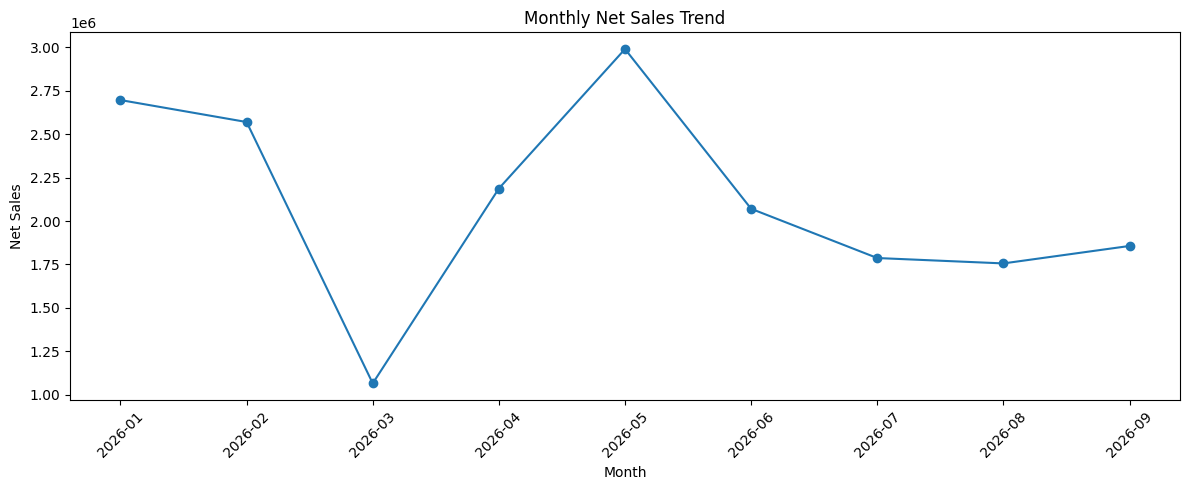

In [46]:
#SALES TREND
monthly_sales = df.groupby('Month')['Net_Sales'].sum()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Net Sales Trend')
plt.xlabel('Month')
plt.ylabel('Net Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

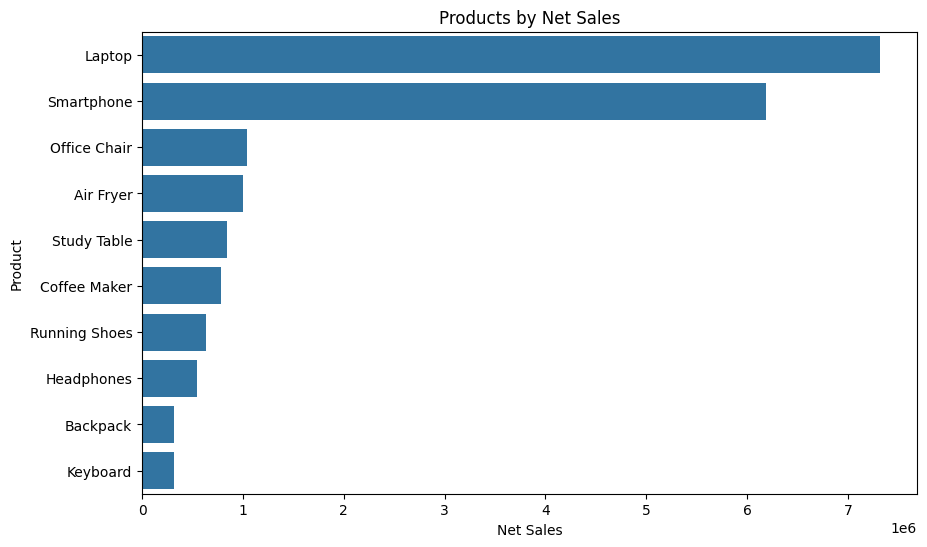

In [47]:
#TOP PRODUCTS VISUALIZATION
top_products = (
    df.groupby('Product')['Net_Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Products by Net Sales')
plt.xlabel('Net Sales')
plt.ylabel('Product')

plt.show()

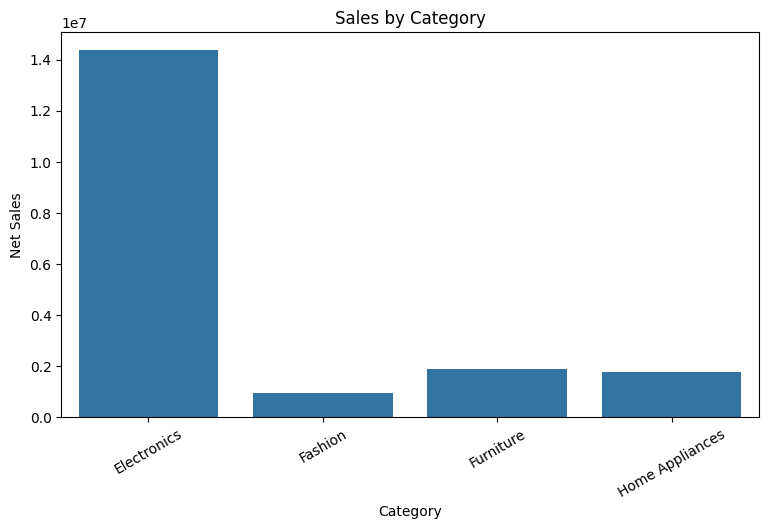

In [48]:
#CATEGORY VISUALIZATION
plt.figure(figsize=(9,5))

sns.barplot(
    data=category_analysis.reset_index(),
    x='Category',
    y='Total_Sales'
)

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Net Sales')

plt.xticks(rotation=30)
plt.show()

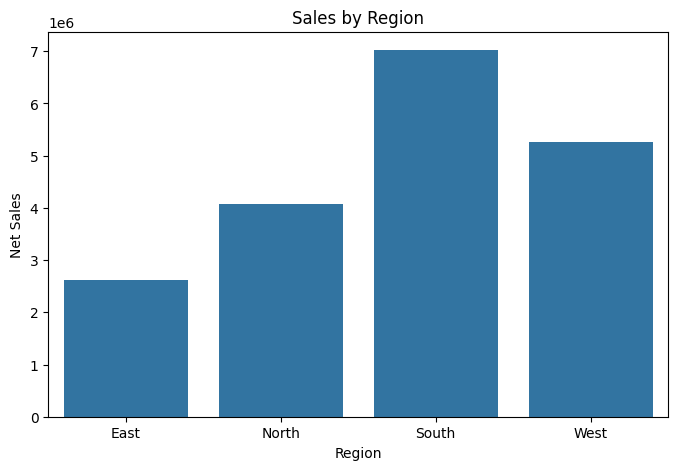

In [49]:
#REGIONAL SALES
plt.figure(figsize=(8,5))

sns.barplot(
    data=region_analysis.reset_index(),
    x='Region',
    y='Total_Sales'
)

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Net Sales')

plt.show()

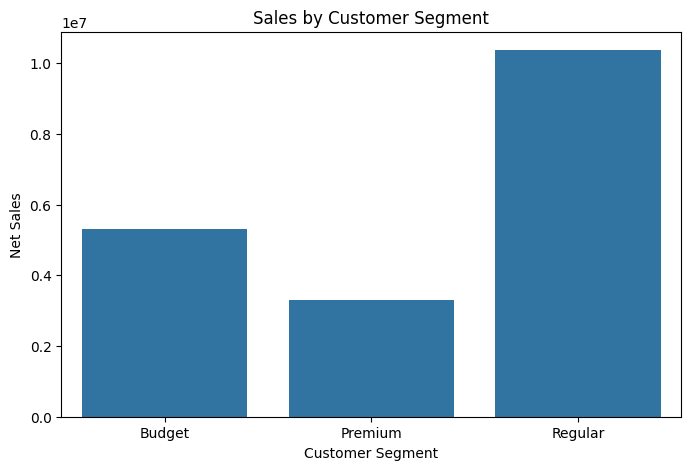

In [50]:
#CUSTOMER SEGMENTS
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_analysis.reset_index(),
    x='Customer_Segment',
    y='Total_Sales'
)

plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Net Sales')

plt.show()

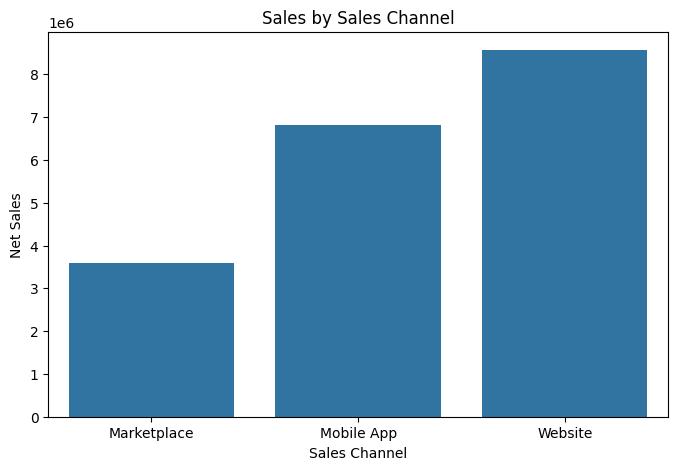

In [51]:
#SALES CHANNEL
plt.figure(figsize=(8,5))

sns.barplot(
    data=channel_analysis.reset_index(),
    x='Sales_Channel',
    y='Total_Sales'
)

plt.title('Sales by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Net Sales')

plt.show()


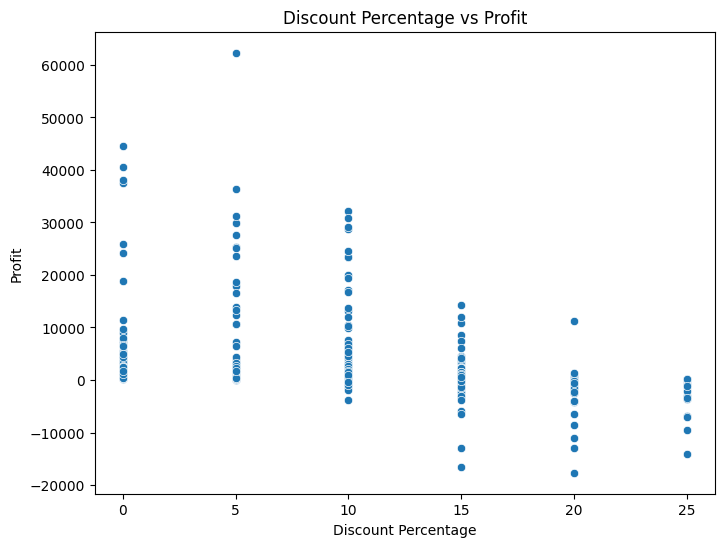

In [52]:
#DISCOUNT VS PROFIT
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Discount_Percent',
    y='Profit'
)

plt.title('Discount Percentage vs Profit')
plt.xlabel('Discount Percentage')
plt.ylabel('Profit')

plt.show()

In [53]:
df[['Discount_Percent', 'Profit']].corr()

,Discount_Percent,Profit
Discount_Percent,1.000000,-0.318417
Profit,-0.318417,1.000000


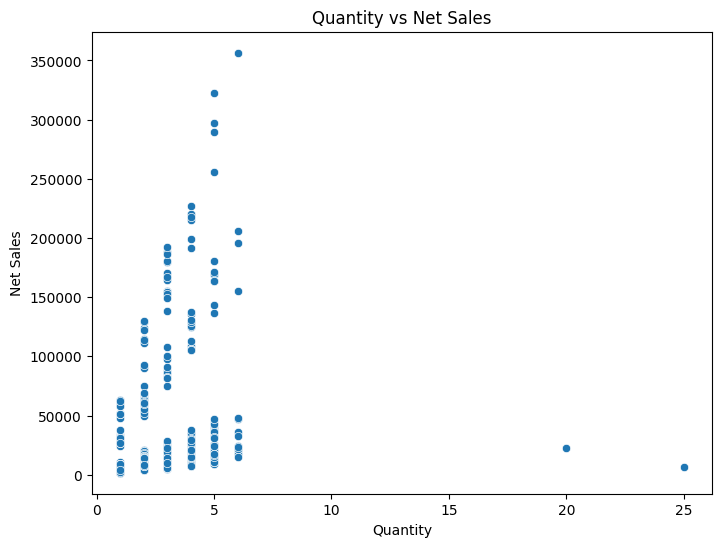

,Quantity,Net_Sales
Quantity,1.000000,0.284949
Net_Sales,0.284949,1.000000


In [54]:
#QUANTITY VS SALES
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Net_Sales'
)

plt.title('Quantity vs Net Sales')
plt.xlabel('Quantity')
plt.ylabel('Net Sales')

plt.show()

df[['Quantity', 'Net_Sales']].corr()

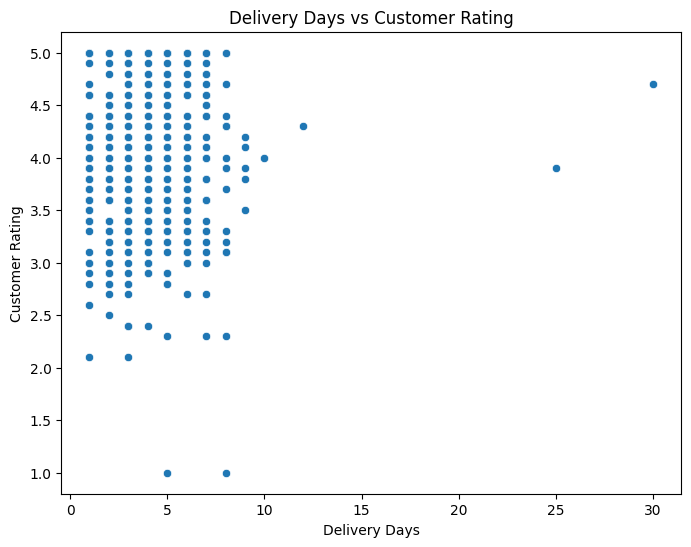

,Delivery_Days,Customer_Rating
Delivery_Days,1.000000,0.038871
Customer_Rating,0.038871,1.000000


In [55]:
#DELIVERY VS CUSTOMER RATING
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Delivery_Days',
    y='Customer_Rating'
)

plt.title('Delivery Days vs Customer Rating')
plt.xlabel('Delivery Days')
plt.ylabel('Customer Rating')

plt.show()

df[['Delivery_Days', 'Customer_Rating']].corr()

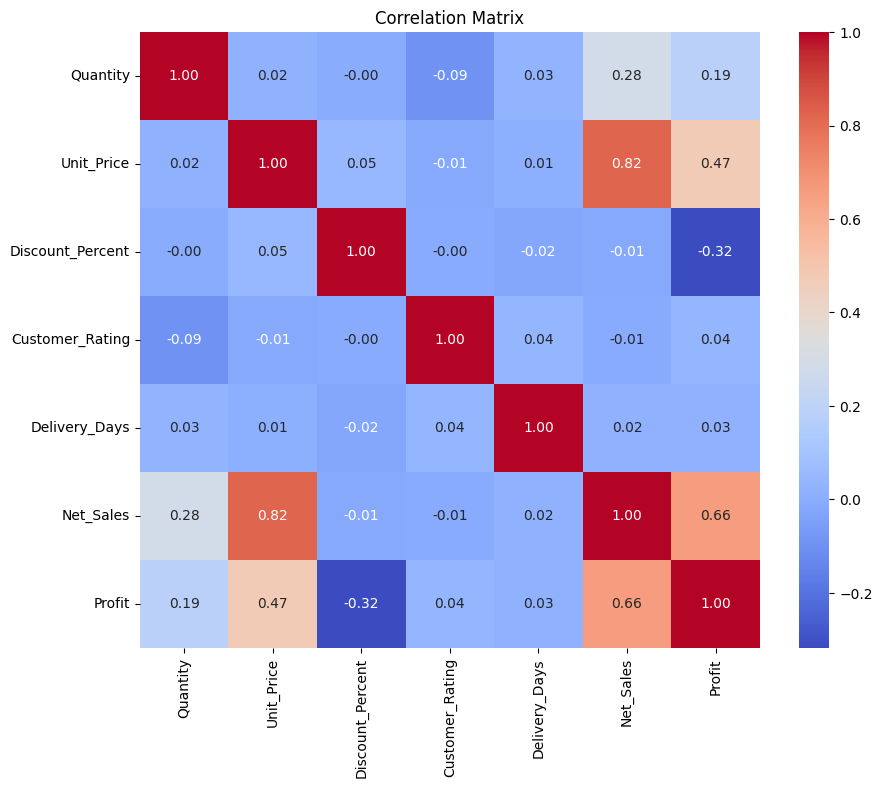

In [56]:
#COMPLETE CORRELATION MATRIX
corr_columns = [
    'Quantity',
    'Unit_Price',
    'Discount_Percent',
    'Customer_Rating',
    'Delivery_Days',
    'Net_Sales',
    'Profit'
]

correlation = df[corr_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

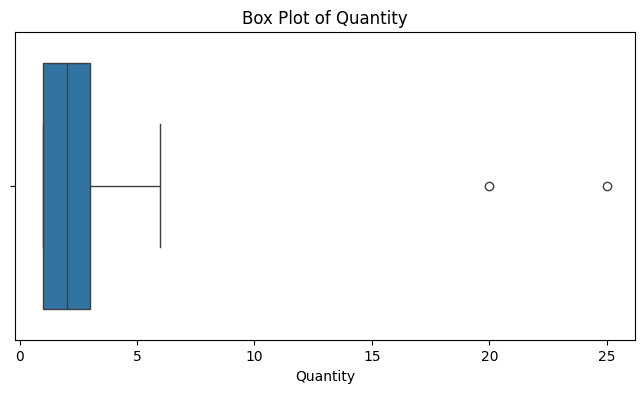

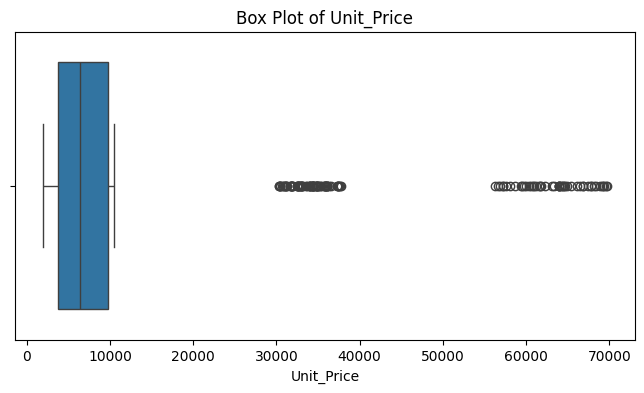

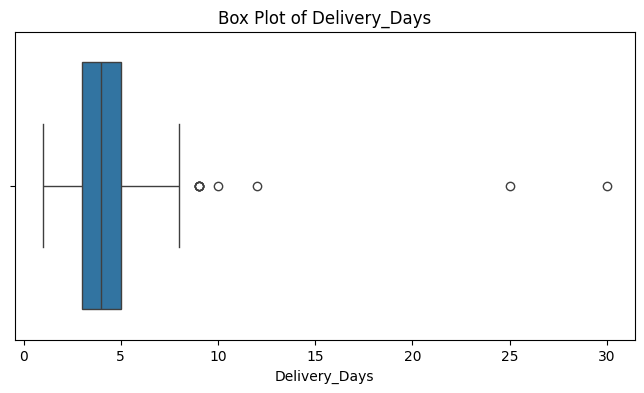

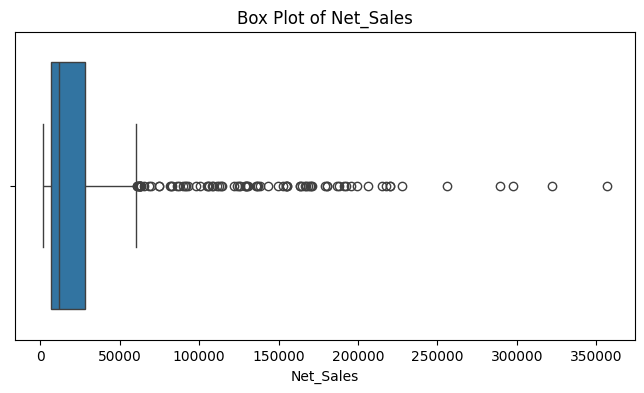

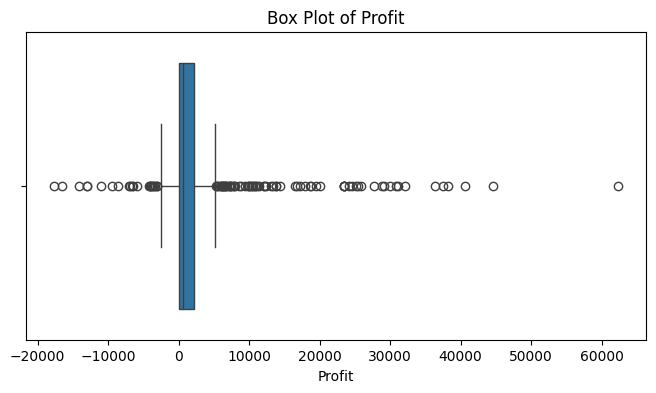

In [57]:
#OUTLIER ANALYSIS
outlier_columns = [
    'Quantity',
    'Unit_Price',
    'Delivery_Days',
    'Net_Sales',
    'Profit'
]

for column in outlier_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

In [58]:
#IQR CALCULATION
def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print("Column:", column)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

    return outliers


quantity_outliers = find_outliers('Quantity')

price_outliers = find_outliers('Unit_Price')

delivery_outliers = find_outliers('Delivery_Days')

sales_outliers = find_outliers('Net_Sales')

profit_outliers = find_outliers('Profit')

Column: Quantity
Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0
Number of Outliers: 2
Column: Unit_Price
Q1: 3801.2
Q3: 9723.164999999999
IQR: 5921.964999999999
Lower Bound: -5081.747499999999
Upper Bound: 18606.112499999996
Number of Outliers: 128
Column: Delivery_Days
Q1: 3.0
Q3: 5.0
IQR: 2.0
Lower Bound: 0.0
Upper Bound: 8.0
Number of Outliers: 9
Column: Net_Sales
Q1: 6364.7325
Q3: 27929.510000000002
IQR: 21564.777500000004
Lower Bound: -25982.433750000004
Upper Bound: 60276.676250000004
Number of Outliers: 84
Column: Profit
Q1: 59.9375
Q3: 2124.5325
IQR: 2064.595
Lower Bound: -3036.955
Upper Bound: 5221.424999999999
Number of Outliers: 94


In [59]:
#HIGH SALES, LOW PROFIT
product_performance = df.groupby('Product').agg(
    Sales=('Net_Sales', 'sum'),
    Profit=('Profit', 'sum')
)

product_performance['Profit_Margin'] = (
    product_performance['Profit'] /
    product_performance['Sales'] * 100
)

product_performance.sort_values(
    'Sales',
    ascending=False
)


,Sales,Profit,Profit_Margin
Product,,,
Laptop,7318291.18,506291.18,6.918161
Smartphone,6181982.26,525982.26,8.508311
Office Chair,1043733.31,76533.31,7.332650
Air Fryer,1001668.06,87268.06,8.712273
Study Table,837809.64,56609.64,6.756862
Coffee Maker,783934.28,63934.28,8.155566
Running Shoes,632938.17,48438.17,7.652907
Headphones,547936.14,42336.14,7.726473
Backpack,321362.82,31562.82,9.821553


In [60]:
#CITY ANALYSIS
city_analysis = df.groupby('City').agg(
    Sales=('Net_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Customers=('Customer_ID', 'nunique')
)

city_analysis['Profit_Margin'] = (
    city_analysis['Profit'] /
    city_analysis['Sales'] * 100
)

city_analysis.sort_values('Sales', ascending=False)

,Sales,Profit,Transactions,Customers,Profit_Margin
City,,,,,
Chennai,2386571.91,139871.91,68,57,5.860788
Bengaluru,2376221.69,237421.69,67,54,9.991563
Hyderabad,2190547.19,163247.19,61,47,7.452348
Pune,1849055.66,168155.66,60,50,9.094137
Ahmedabad,1726884.42,93784.42,59,49,5.430845
Mumbai,1707495.70,59395.70,59,53,3.478527
Jaipur,1551104.05,196604.05,50,42,12.675104
Delhi,1505855.07,116455.07,40,32,7.733485
Bhubaneswar,1466507.98,97007.98,42,36,6.614896


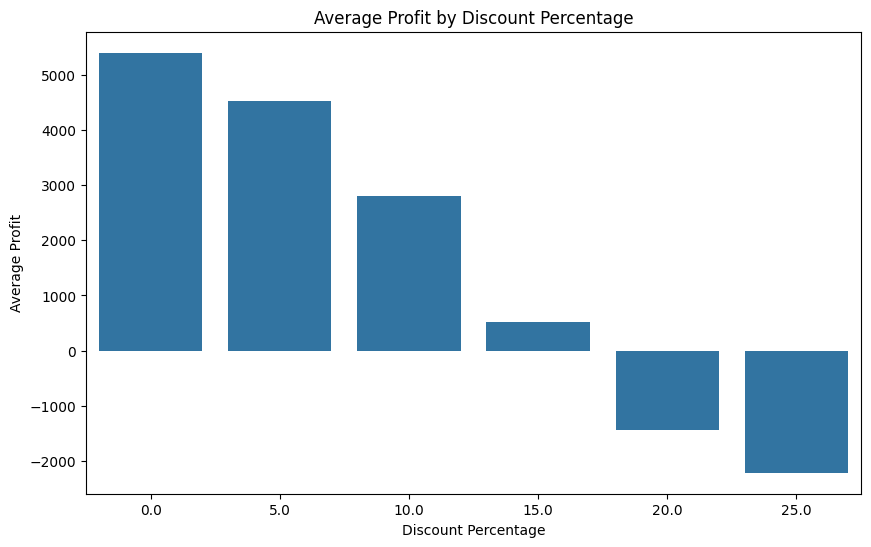

In [61]:
#DISCOUNT ANALYSIS
discount_analysis = df.groupby('Discount_Percent').agg(
    Sales=('Net_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Transactions=('Transaction_ID', 'count'),
    Average_Profit=('Profit', 'mean')
)

discount_analysis


plt.figure(figsize=(10,6))

sns.barplot(
    x=discount_analysis.index,
    y=discount_analysis['Average_Profit']
)

plt.title('Average Profit by Discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Average Profit')

plt.show()

In [62]:
#PAYMENT METHOD ANALYSIS
payment_analysis = df.groupby('Payment_Method').agg(
    Transactions=('Transaction_ID', 'count'),
    Sales=('Net_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Average_Order_Value=('Net_Sales', 'mean')
)

payment_analysis

,Transactions,Sales,Profit,Average_Order_Value
Payment_Method,,,,
Cash,120,4353125.45,266625.45,36276.045417
Credit Card,126,4535887.13,377687.13,35999.104206
Debit Card,138,3356995.74,314795.74,24326.056087
Net Banking,100,2871009.80,254309.80,28710.098000
UPI,116,3864954.89,254054.89,33318.576638
